In [1]:
import cv2

In [2]:
import cv2, os
path = os.path.join(cv2.data.haarcascades, "haarcascade_frontalface_default.xml")
print(path, os.path.isfile(path))

C:\Users\mejor\AppData\Local\Programs\Python\Python313\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml True


In [3]:
!pip install tf_keras


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from deepface import DeepFace

In [5]:
img = cv2.imread('happy.jpg')

In [6]:
import matplotlib.pyplot as plt

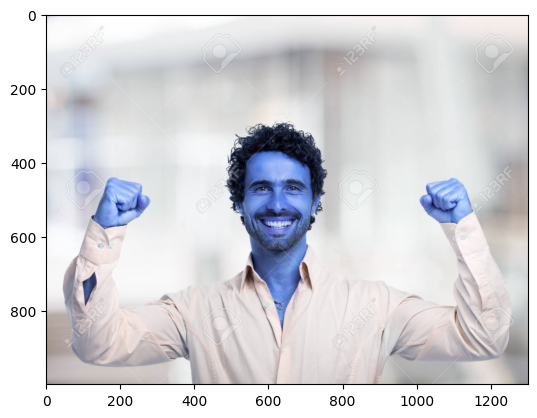

In [7]:
plt.imshow(img)

In [8]:
predictions = DeepFace.analyze(img)

Action: race: 100%|██████████| 4/4 [00:08<00:00,  2.19s/it]   


In [9]:
predictions

[{'emotion': {'angry': np.float32(1.3073136e-15),
   'disgust': np.float32(7.1224466e-25),
   'fear': np.float32(8.2981346e-16),
   'happy': np.float32(99.999664),
   'sad': np.float32(1.3771807e-13),
   'surprise': np.float32(5.9110763e-12),
   'neutral': np.float32(0.0003324927)},
  'dominant_emotion': 'happy',
  'region': {'x': 498,
   'y': 368,
   'w': 255,
   'h': 255,
   'left_eye': (662, 470),
   'right_eye': (580, 472)},
  'face_confidence': 0.85,
  'age': 32,
  'gender': {'Woman': np.float32(1.4882066e-05), 'Man': np.float32(99.999985)},
  'dominant_gender': 'Man',
  'race': {'asian': np.float32(0.00035913868),
   'indian': np.float32(0.12430323),
   'black': np.float32(0.001855602),
   'white': np.float32(89.12548),
   'middle eastern': np.float32(9.086492),
   'latino hispanic': np.float32(1.661511)},
  'dominant_race': 'white'}]

In [10]:
type(predictions)

list

In [11]:
predictions[0]['dominant_emotion']

'happy'

# we are trying to draw a ractangle across the face

In [12]:
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [13]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # print(faceCascade.empty())
faces = faceCascade.detectMultiScale(gray,1.1,4)

    # Draw a rectangle around the faces
for(x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

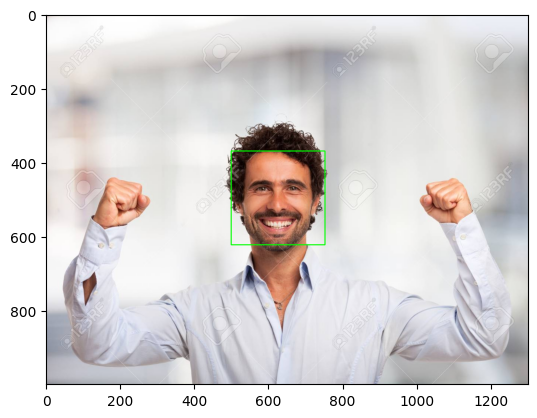

In [14]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [15]:
font = cv2.FONT_HERSHEY_SIMPLEX

    # Use putText() method for
    # inserting text on video
cv2.putText(img,
            predictions[0]['dominant_emotion'],
            (0, 50),
            font,
            1,        # smaller text
            (255, 0, 0),
            2,
            cv2.LINE_4);

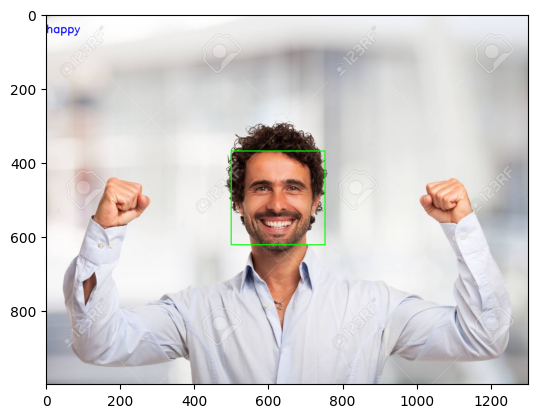

In [16]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [17]:
img = cv2.imread('neutral.jpg')

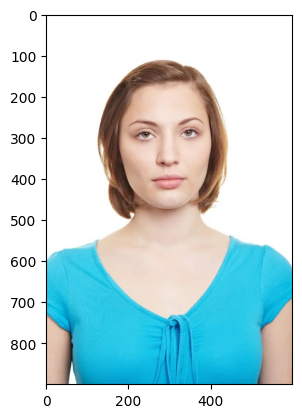

In [18]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [19]:
predictions = DeepFace.analyze(img)

Action: race: 100%|██████████| 4/4 [00:01<00:00,  2.30it/s]  


In [20]:
predictions

[{'emotion': {'angry': np.float32(0.0028584155),
   'disgust': np.float32(1.3538385e-06),
   'fear': np.float32(0.08417394),
   'happy': np.float32(0.1323108),
   'sad': np.float32(0.36844853),
   'surprise': np.float32(0.00061529485),
   'neutral': np.float32(99.41159)},
  'dominant_emotion': 'neutral',
  'region': {'x': 159,
   'y': 184,
   'w': 274,
   'h': 274,
   'left_eye': (346, 287),
   'right_eye': (237, 293)},
  'face_confidence': 0.88,
  'age': 29,
  'gender': {'Woman': np.float32(99.999985), 'Man': np.float32(1.2130436e-05)},
  'dominant_gender': 'Woman',
  'race': {'asian': np.float32(0.55485594),
   'indian': np.float32(0.43760365),
   'black': np.float32(0.044485964),
   'white': np.float32(70.0576),
   'middle eastern': np.float32(14.846392),
   'latino hispanic': np.float32(14.059059)},
  'dominant_race': 'white'}]

# Real time video demo for Face Emotion Recognition 

In [ ]:
import cv2 ### pip install opencv-python
 ## pip install opencv-contrib-python fullpackage
from deepface import DeepFace ## pip install deepface

faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

cap = cv2.VideoCapture(1)
# Check if the webcam is opened correctly
if not cap.isOpened():
    cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open webcam")

font = cv2.FONT_HERSHEY_SIMPLEX  # define this once, at the top, before the loop

while True:
    ret, frame = cap.read()

    result = DeepFace.analyze(frame, actions=['emotion'], enforce_detection=False)

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    cv2.putText(frame,
                result[0]['dominant_emotion'],
                (50, 100),
                font, 3,
                (255, 0, 0),
                2,
                cv2.LINE_4)

    cv2.imshow('Emotion Recognition Camera', frame)

    if cv2.waitKey(2) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()